In [1]:
import utils
import pandas as pd
import os
import importlib

importlib.reload(utils)

#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 150)

<module 'utils' from '/Volumes/kenvdzee/Documents/phd_1_analysis/utils/__init__.py'>

In [2]:
# Preparation
dataset = 'TUS' # TUS, joystick, speakup, africa

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [52, 53, 54, 55, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/190526/raw'
    unique_subject_ids = [2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/{dataset}/behavioural/win-stay_lose-shift'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset)

sub-059 did not complete session-03
sub-059 did not complete session-04
sub-062 did not complete session-02
sub-062 did not complete session-03
sub-062 did not complete session-04
sub-063 did not complete session-04
sub-065 did not complete session-03
sub-065 did not complete session-04
sub-066 did not complete session-03
sub-066 did not complete session-04
sub-067 did not complete session-04
sub-068 did not complete session-03
sub-068 did not complete session-04
sub-069 did not complete session-02
sub-069 did not complete session-03
sub-069 did not complete session-04
These participants will be excluded: {'sub-011_session-02', 'sub-016_session-04', 'sub-011_session-04', 'sub-011_session-03', 'sub-011_session-01'}



In [3]:
#combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['trials_since_reversal_separate_learning']<=10]

# For plotting purposes
combined_results_dataframe['win-stay'] = combined_results_dataframe['win-stay'].replace(1, 100)
combined_results_dataframe['lose-stay'] = combined_results_dataframe['lose-stay'].replace(1, 100)

# Win-stay plots
# Objective win-stay behaviour

# Sanity checks

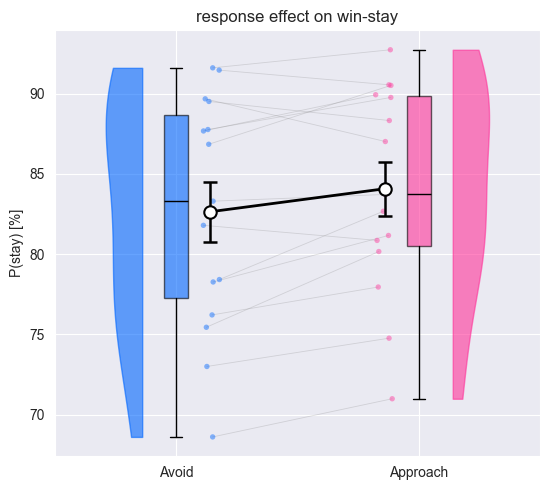

In [4]:
# Check for a response bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='response',
        values='win-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['avoid','approach'],
    labels=['Avoid', 'Approach'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='P(stay) [%]',
    plot_name='response effect on win-stay'
);

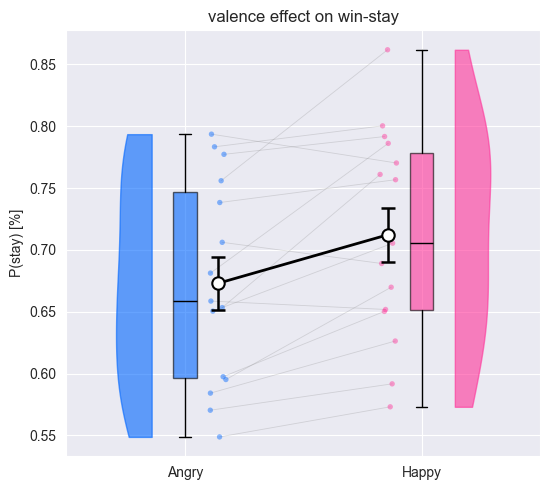

In [5]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='valence',
        values='stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry', 'happy'],
    labels=['Angry', 'Happy'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='P(stay) [%]',
    plot_name='valence effect on win-stay'
);

# Actual analyses

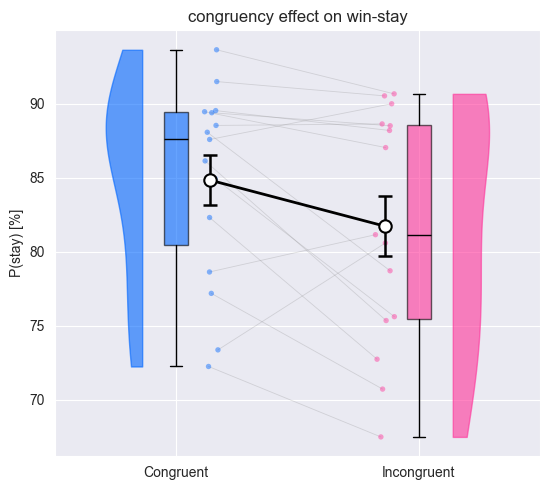

In [6]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='win-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent','incongruent'],
    labels=['Congruent', 'Incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='P(stay) [%]',
    plot_name='congruency effect on win-stay'
);

In [7]:
if dataset == 'africa':
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index='subject_id',
            columns=['congruency', 'stimulation_condition'],
            values='win-stay',
            aggfunc='mean'
        )
    )
    combined_results_pivoted.columns = [f'{congruency}_{condition}' for congruency, condition in combined_results_pivoted.columns]
    combined_results_pivoted = combined_results_pivoted.reset_index()

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['congruent_uwd','incongruent_uwd','congruent_control','incongruent_control'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='uwd effect on congruency effect on win-stay'
    );

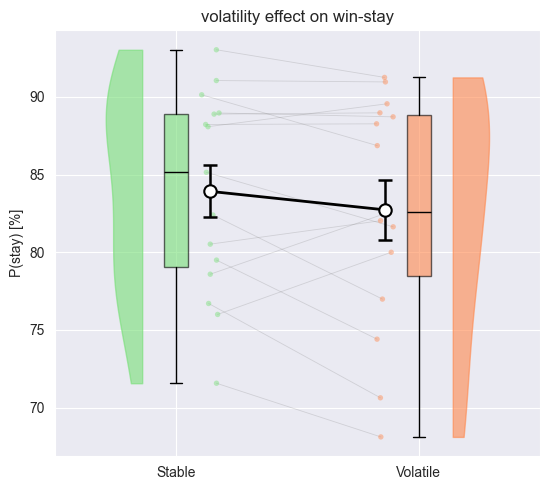

In [8]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='win-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        labels=['Stable', 'Volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='volatility effect on win-stay',
        colours=['#77DF77', '#FF884D']
    );

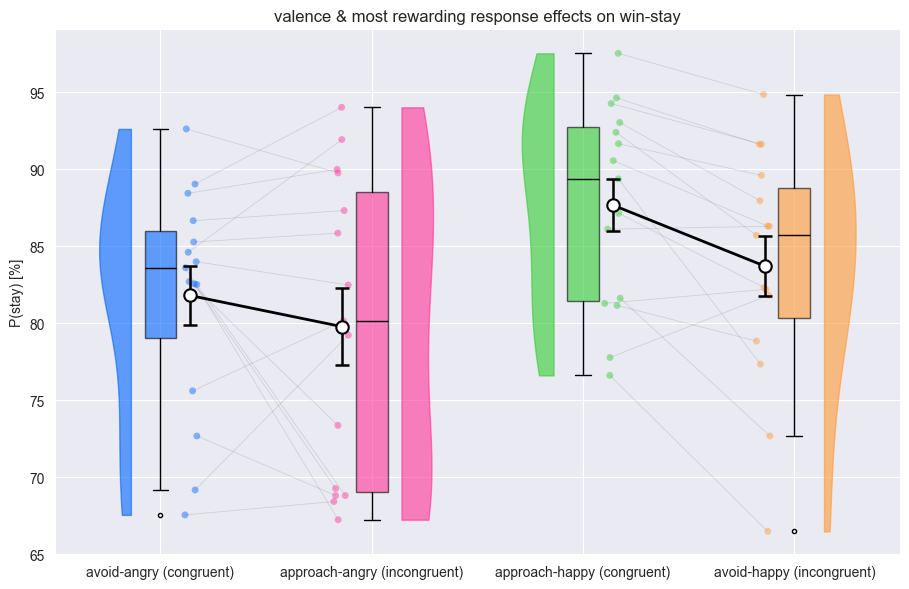

In [9]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns=['most_rewarding_response', 'valence'],
            values='win-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='valence & most rewarding response effects on win-stay'
    );

In [10]:
if dataset == 'africa':
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index='subject_id',
            columns=['most_rewarding_response', 'valence', 'stimulation_condition'],
            values='win-stay',
            aggfunc='mean'
        )
    )
    combined_results_pivoted.columns = [f'{response}_{valence}_{condition}' for response, valence, condition in combined_results_pivoted.columns]
    combined_results_pivoted = combined_results_pivoted.reset_index()

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry_uwd','approach_angry_uwd','avoid_angry_control','approach_angry_control','approach_happy_uwd','avoid_happy_uwd','approach_happy_control','avoid_happy_control'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='uwd effect on valence & most rewarding response effects on win-stay'
    );

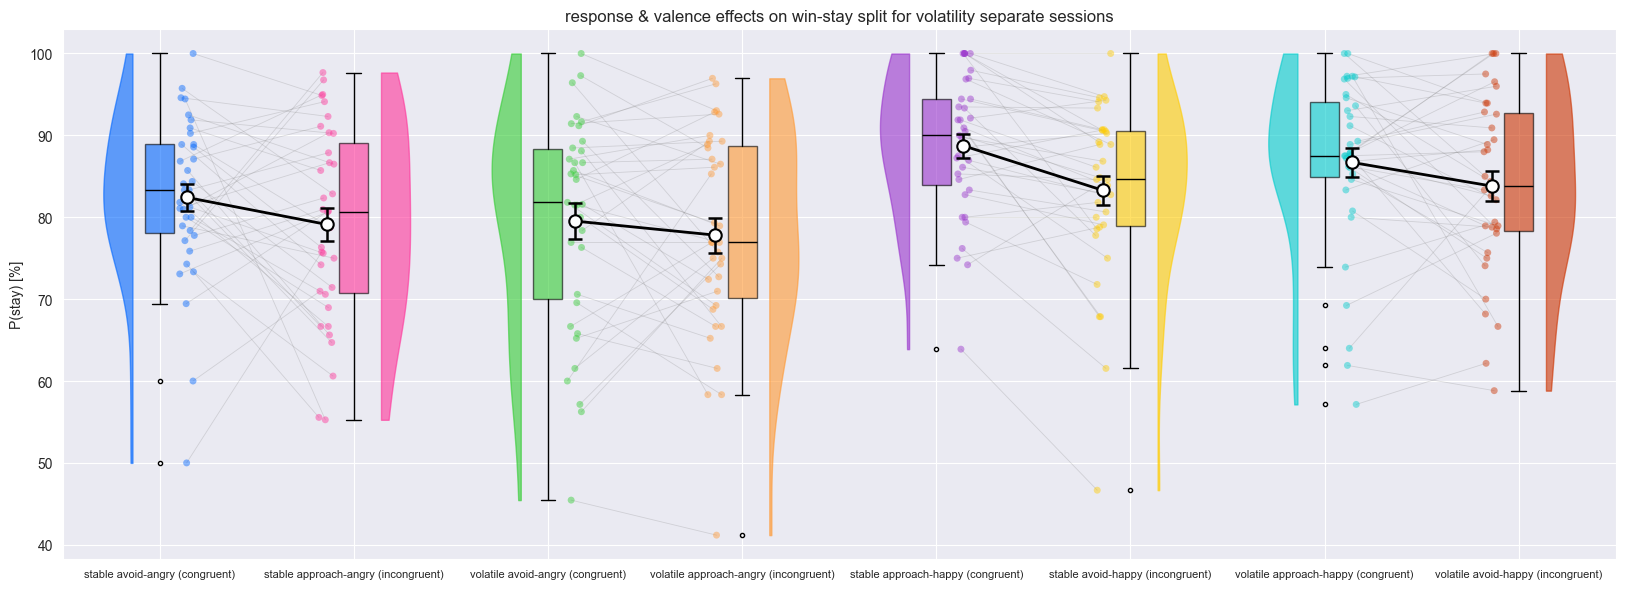

In [11]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id','session'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='win-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='response & valence effects on win-stay split for volatility separate sessions'
    );

# lose-stay plots
## Objective lose-stay behaviour

# Sanity checks

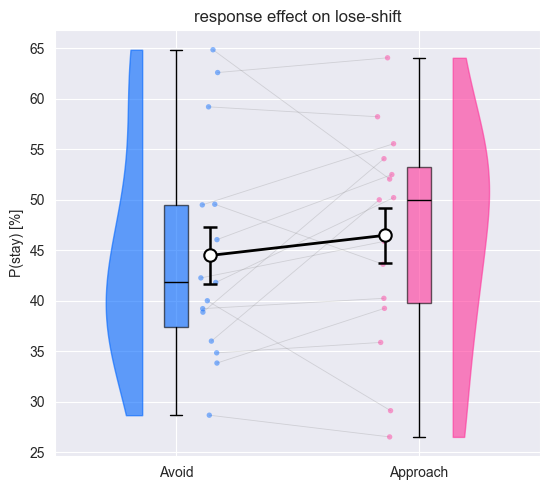

In [12]:
# Check for response bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='response',
        values='lose-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['avoid','approach'],
    labels=['Avoid', 'Approach'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='P(stay) [%]',
    plot_name='response effect on lose-shift'
);

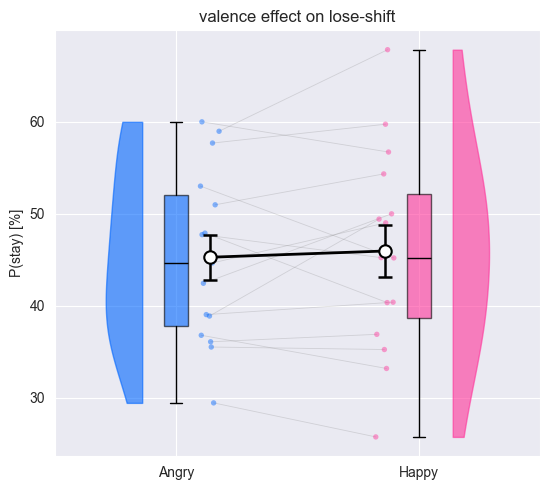

In [13]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='valence',
        values='lose-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry','happy'],
    labels=['Angry', 'Happy'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='P(stay) [%]',
    plot_name='valence effect on lose-shift'
);

# Actual analyses

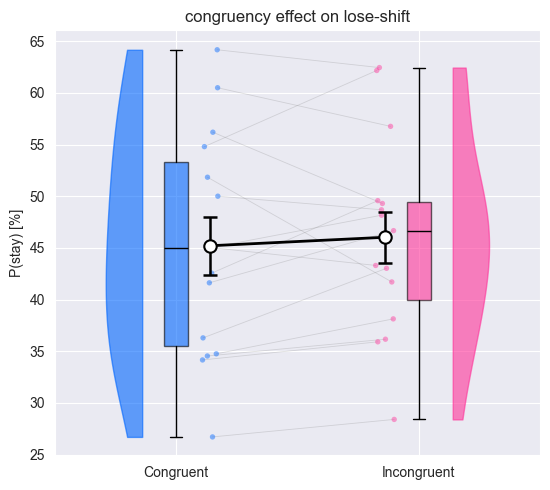

In [14]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='lose-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent','incongruent'],
    labels=['Congruent', 'Incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='P(stay) [%]',
    plot_name='congruency effect on lose-shift'
);

In [15]:
if dataset == 'africa':
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index='subject_id',
            columns=['congruency', 'stimulation_condition'],
            values='lose-stay',
            aggfunc='mean'
        )
    )
    combined_results_pivoted.columns = [f'{congruency}_{condition}' for congruency, condition in combined_results_pivoted.columns]
    combined_results_pivoted = combined_results_pivoted.reset_index()

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['congruent_uwd','incongruent_uwd','congruent_control','incongruent_control'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='uwd effect on congruency effect on lose-shift'
    );

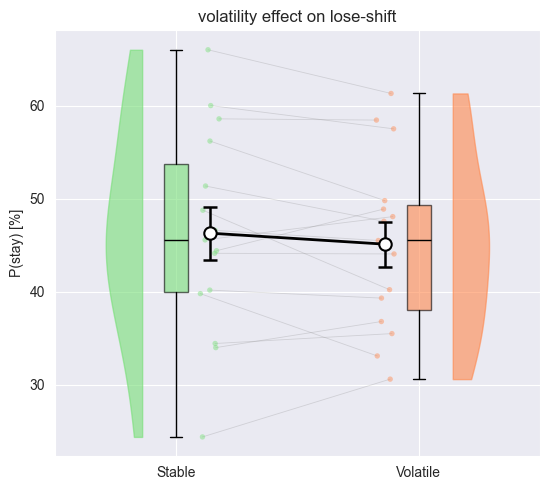

In [16]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='lose-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        labels=['Stable', 'Volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='volatility effect on lose-shift',
        colours=['#77DF77', '#FF884D']
    );

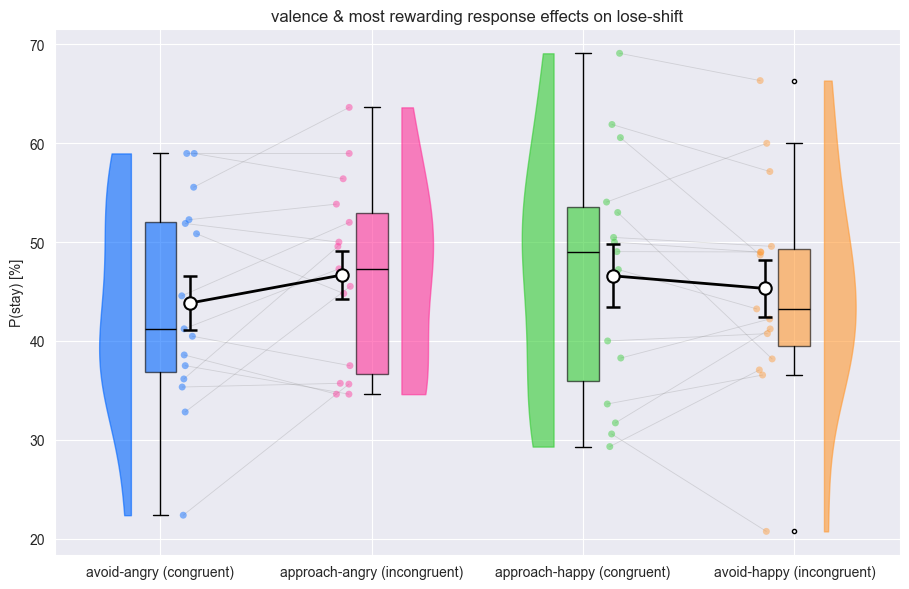

In [17]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns=['most_rewarding_response', 'valence'],
            values='lose-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='valence & most rewarding response effects on lose-shift'
    );

In [18]:
if dataset == 'africa':
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index='subject_id',
            columns=['most_rewarding_response', 'valence', 'stimulation_condition'],
            values='lose-stay',
            aggfunc='mean'
        )
    )
    combined_results_pivoted.columns = [f'{response}_{valence}_{condition}' for response, valence, condition in combined_results_pivoted.columns]
    combined_results_pivoted = combined_results_pivoted.reset_index()

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry_uwd','approach_angry_uwd','avoid_angry_control','approach_angry_control','approach_happy_uwd','avoid_happy_uwd','approach_happy_control','avoid_happy_control'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='uwd effect on valence & most rewarding response effects on lose-shift'
    );

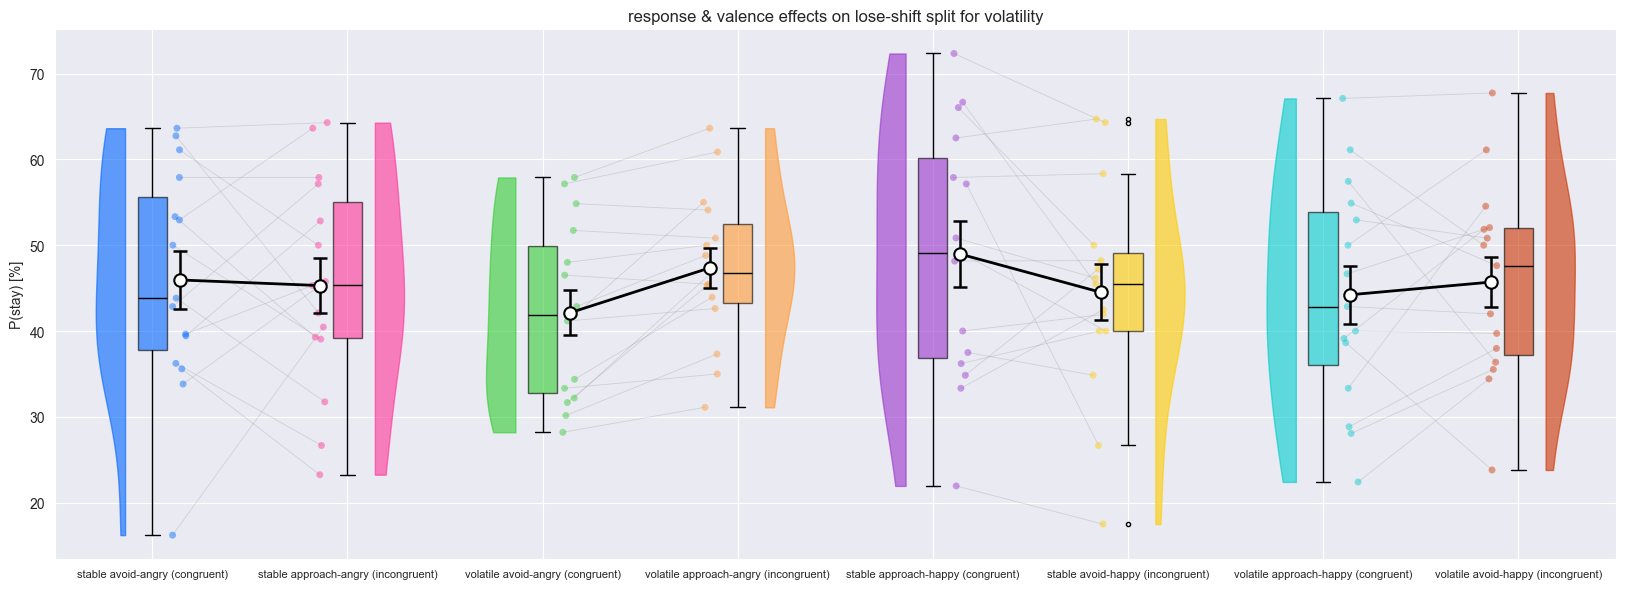

In [19]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='lose-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='response & valence effects on lose-shift split for volatility'
    );

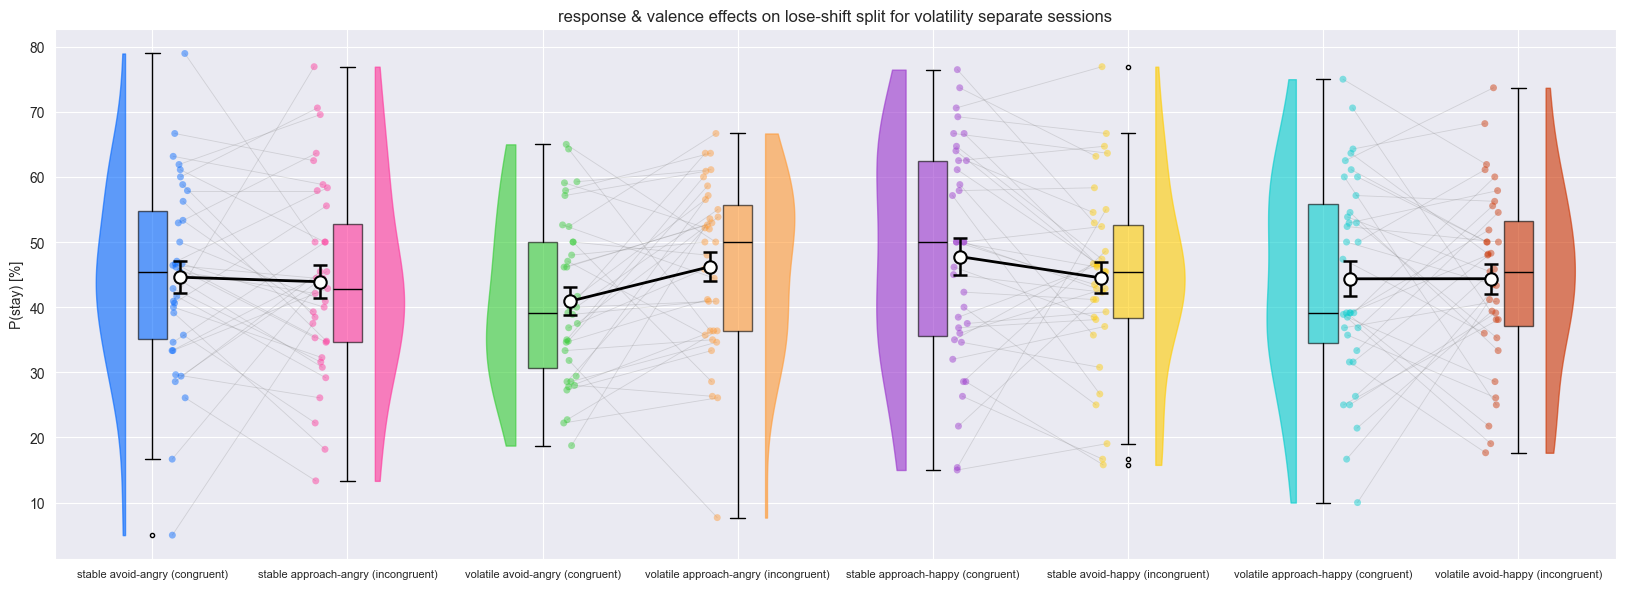

In [20]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id','session'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='lose-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='P(stay) [%]',
        plot_name='response & valence effects on lose-shift split for volatility separate sessions'
    );